# Student t Copula for Portfolio Risk Analysis

This notebook demonstrates the implementation and usage of Student t copula for portfolio risk analysis. The Student t copula is particularly useful in finance as it exhibits symmetric tail dependence, making it suitable for modeling extreme events in both market upturns and downturns.

Key features of this implementation:
- Transforms return data into pseudo-observations using empirical distribution
- Fits a Student t copula to capture the dependence structure between assets
- Calculates Value at Risk (VaR) and Conditional Value at Risk (CVaR)
- Handles portfolio weights and returns data efficiently

The Student t copula provides a robust way to model symmetric tail dependence in financial returns, particularly useful for risk management and portfolio optimization.


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Basic Statistics:
               JPM          BAC          WFC           GS
count  6564.000000  6564.000000  6564.000000  6564.000000
mean      0.000629     0.000515     0.000579     0.000644
std       0.023533     0.027424     0.023883     0.022863
min      -0.207274    -0.289694    -0.238223    -0.189597
25%      -0.008890    -0.009674    -0.008428    -0.010111
50%       0.000297     0.000287     0.000197     0.000363
75%       0.009817     0.010258     0.008989     0.011141
max       0.250967     0.352691     0.327645     0.264678


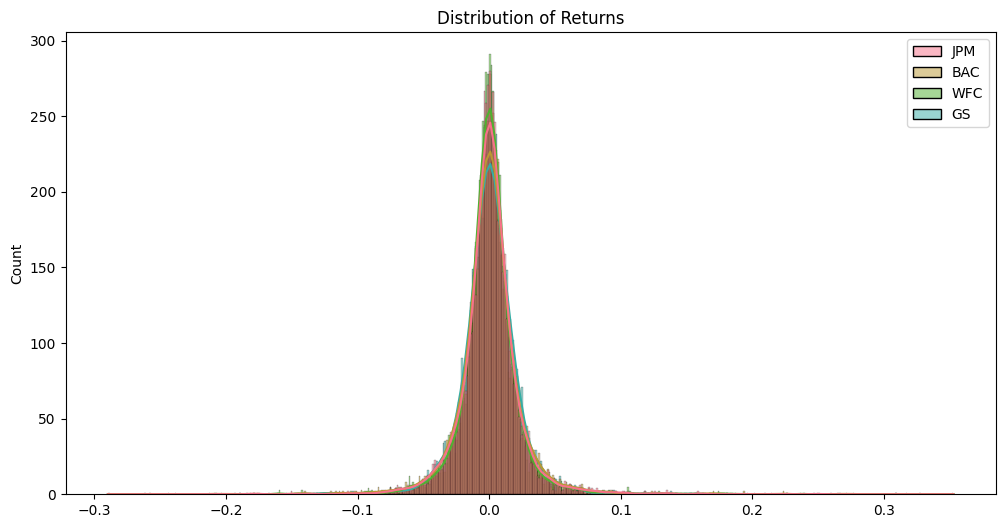

In [2]:
from helper import get_data
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_palette('husl')

df = get_data(["JPM", "BAC", "WFC", "GS"])
returns = df.pct_change().dropna()

# Basic statistics
print("Basic Statistics:")
print(returns.describe())


# Plot returns distribution
plt.figure(figsize=(12, 6))
sns.histplot(returns, kde=True)
plt.title('Distribution of Returns')
plt.show()

This code demonstrates the implementation of a Student t copula for portfolio risk analysis.
The key steps are:
#
1. Data Preparation:
   - Loads stock data for major banks (JPM, BAC, WFC, GS)
   - Calculates daily returns and drops missing values
   - Displays basic statistics and plots return distributions
#
2. Copula Implementation:
   - Converts returns to numpy array for efficient computation
   - Sets up simulation parameters (100,000 samples)
   - Calculates correlation matrix and its Cholesky decomposition
   - Generates Student t distributed samples with 4 degrees of freedom
   - Transforms samples to uniform marginals using t CDF
The Student t copula captures symmetric tail dependence between assets,
making it suitable for modeling extreme market events in both directions.


In [3]:
from scipy.stats import t as student_t
import numpy as np

returns = returns.to_numpy()
(n_assets, size) = (returns.shape[1], 100000)

# Calculate correlation matrix
corr_matrix = np.corrcoef(returns, rowvar=False)
cholesky_matrix = np.linalg.cholesky(corr_matrix)

# Generate Student t samples
df = 4  # degrees of freedom
s = np.random.chisquare(df, size)
Z = np.random.multivariate_normal(
    np.zeros(n_assets),
    np.eye(n_assets),
    size
)
X = Z.dot(cholesky_matrix.T) * np.sqrt(df / s[:, np.newaxis])

# Transform to uniform using t CDF
U = student_t.cdf(X, df)

U_scaled = np.empty_like(U)
for i in range(n_assets):
    U_scaled[:, i] = np.quantile(returns[:, i], U[:, i])

- Plotting the dependency structure

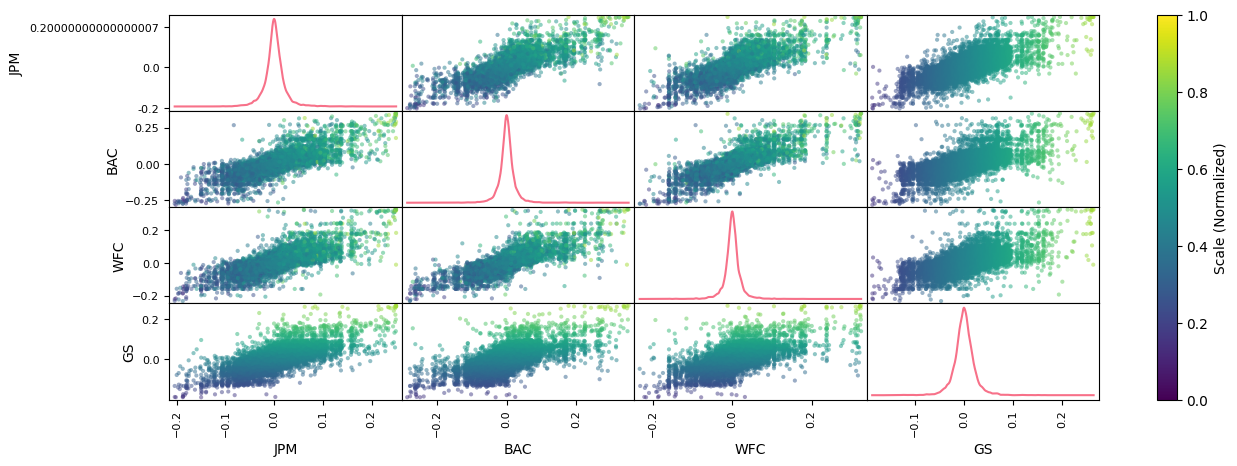

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(U_scaled)
df.columns = ["JPM", "BAC", "WFC", "GS"]

# Use U4 as the color variable
colors = df["GS"]

# Create the scatter matrix with colors
pd.plotting.scatter_matrix(df, alpha=0.5, figsize=(15, 5), diagonal='kde', c=colors, cmap='viridis')

# Add a colorbar to show the mapping of color to U4
cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=plt.gcf().axes)
cbar.set_label('Scale (Normalized)')

plt.show()

## Dependency Structure Analysis
# 
This section visualizes the dependency structure between all assets in our portfolio. The analysis includes:
# 
- Scatter matrix plots showing pairwise relationships between assets
- 3D visualization of the first three assets with the fourth asset represented by color
- Correlation patterns and clustering behavior
- Identification of potential tail dependencies
# 
These visualizations help us understand how the assets move together and identify any non-linear relationships or extreme co-movements.

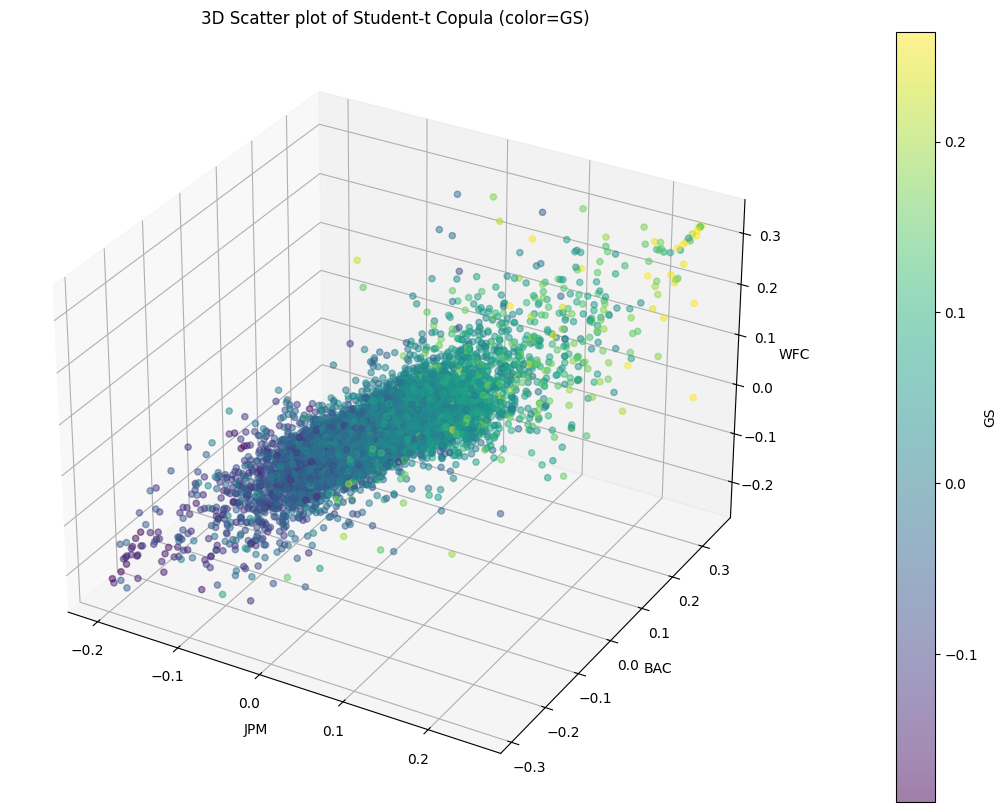

In [5]:
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')

# Use U_scaled[:, 3] as the color
sc = ax.scatter(U_scaled[:, 0], U_scaled[:, 1], U_scaled[:, 2], c=U_scaled[:, 3], cmap='viridis', alpha=0.5)
ax.set_xlabel('JPM')
ax.set_ylabel('BAC')
ax.set_zlabel('WFC')
ax.set_title('3D Scatter plot of Student-t Copula (color=GS)')

# Add a colorbar to show the mapping of color to U[:, 3]
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label('GS')

plt.show()

## Portfolio Risk Analysis

# 
In this section, we analyze the risk characteristics of an equally-weighted portfolio
composed of the four assets. We calculate key risk metrics including Value at Risk (VaR)
and Expected Shortfall (ES) at the 95% confidence level. The analysis includes:
# 
- Portfolio return distribution visualization
- VaR and ES calculations
- Q-Q plot for normality assessment
- Additional risk metrics (mean, standard deviation, skewness, kurtosis)
# 
This analysis helps us understand the portfolio's risk profile and potential tail risks.


Portfolio Statistics:
95% VaR: -0.0292
95% Expected Shortfall: -0.0481


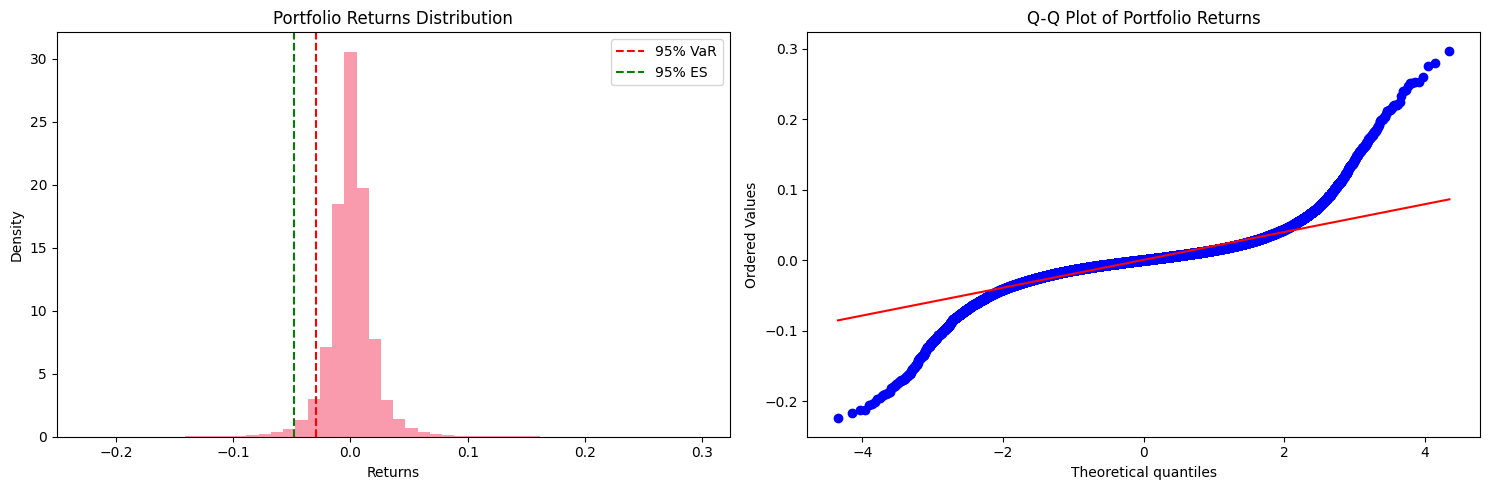


Additional Portfolio Metrics:
Mean Return: 0.0005
Standard Deviation: 0.0214
Skewness: 0.6502
Kurtosis: 15.9285


In [8]:
from scipy import stats

WEIGHTS = np.array([0.25, 0.25, 0.25, 0.25])

portfolio = np.dot(WEIGHTS, U_scaled.T)
# Calculate portfolio VaR and ES
VaR_95 = np.percentile(portfolio, 5)
ES_95 = np.mean(portfolio[portfolio <= VaR_95])

print(f"\nPortfolio Statistics:")
print(f"95% VaR: {VaR_95:.4f}")
print(f"95% Expected Shortfall: {ES_95:.4f}")

# Plot portfolio returns distribution
plt.figure(figsize=(15, 5))

# Histogram of portfolio returns
plt.subplot(121)
plt.hist(portfolio, bins=50, density=True, alpha=0.7)
plt.axvline(VaR_95, color='r', linestyle='dashed', label='95% VaR')
plt.axvline(ES_95, color='g', linestyle='dashed', label='95% ES')
plt.title('Portfolio Returns Distribution')
plt.xlabel('Returns')
plt.ylabel('Density')
plt.legend()

# QQ plot of portfolio returns
plt.subplot(122)
stats.probplot(portfolio, dist="norm", plot=plt)
plt.title('Q-Q Plot of Portfolio Returns')

plt.tight_layout()
plt.show()

# Calculate some additional portfolio metrics
print(f"\nAdditional Portfolio Metrics:")
print(f"Mean Return: {np.mean(portfolio):.4f}")
print(f"Standard Deviation: {np.std(portfolio):.4f}")
print(f"Skewness: {stats.skew(portfolio):.4f}")
print(f"Kurtosis: {stats.kurtosis(portfolio):.4f}")